# L2 · Hypothesis Testing for Executives

**Concept → Intuition → Math → Code → Executive Takeaway**

---

## WHY This Matters

Every business decision is a hypothesis: "If we do X, Y will happen." Understanding hypothesis testing lets you evaluate claims with data, distinguish signal from noise, and make decisions with confidence rather than intuition.

---

## CONCEPT: What Is a Hypothesis?

A hypothesis is a statement you want to test with data. In business:

- "Our new pricing strategy will increase revenue by 10%"
- "This supplier is more reliable than the alternative"
- "The marketing campaign drove more sales"

The key question: **Can we trust this claim, or is it just noise?**

---

## INTUITION: The Courtroom Analogy

Think of hypothesis testing like a courtroom:

1. **Null Hypothesis (H₀)** = The defendant is innocent (no effect)
2. **Alternative Hypothesis (H₁)** = The defendant is guilty (there is an effect)
3. **Evidence** = Your data
4. **Verdict** = Statistical decision

You start assuming innocence (H₀). Only with enough evidence do you convict (reject H₀).

**In business terms:**
- H₀: "Our changes made no difference"
- H₁: "Our changes actually worked"
- Evidence: The data we collected

---

## MATH: Key Formulas

### The Two Hypotheses

```
H₀: μ = μ₀        (no effect / status quo)
H₁: μ ≠ μ₀        (there is an effect)
```

### P-Value

The probability of seeing results this extreme **if H₀ were true**.

```
p-value < 0.05  →  Reject H₀  →  Statistically significant
p-value ≥ 0.05  →  Fail to reject H₀  →  Not significant
```

### Confidence Interval

The range where the true value likely falls:

```
95% CI = sample mean ± (1.96 × standard error)
```

### Types of Errors

| | Actual: No Effect | Actual: Effect Exists |
|---|---|---|
| **Decision: No Effect** | ✅ Correct | ❌ Type II (False Negative) |
| **Decision: Effect** | ❌ Type I (False Positive) | ✅ Correct |

---

## CODE: Hypothesis Testing in Python

In [1]:
import numpy as np
from scipy import stats

# Example: Did BYD's market share actually change?
# Before: 12.8% | After campaign: 14.2%

before = np.array([12.5, 13.1, 12.2, 12.9, 13.0, 12.7, 12.4, 13.2])
after = np.array([14.1, 14.5, 13.8, 14.3, 13.9, 14.0, 14.4, 14.2])

# Two-sample t-test
t_stat, p_value = stats.ttest_ind(after, before)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"Significant at 5%? {'YES' if p_value < 0.05 else 'NO'}")

T-statistic: 9.119
P-value: 0.000000
Significant at 5%? YES


## Visual Intuition: Three Diagnostic Pictures

The three figures below turn the vocabulary into a visual decision aid:

1. **P-value as area under the null curve** — the shaded tails are outcomes at least as extreme as the observed statistic if H₀ were true.
2. **Type I vs. Type II errors** — the same cutoff creates two different mistakes, depending on which distribution is the truth.
3. **Confidence interval** — the whisker shows a plausible range for the population mean, not a guarantee about any one future observation.

All figures use the same dark theme and are exported as PNGs under `outputs/learning/` so they can be reused in an executive slide.

Visualization saved: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l2_p_value_area.png


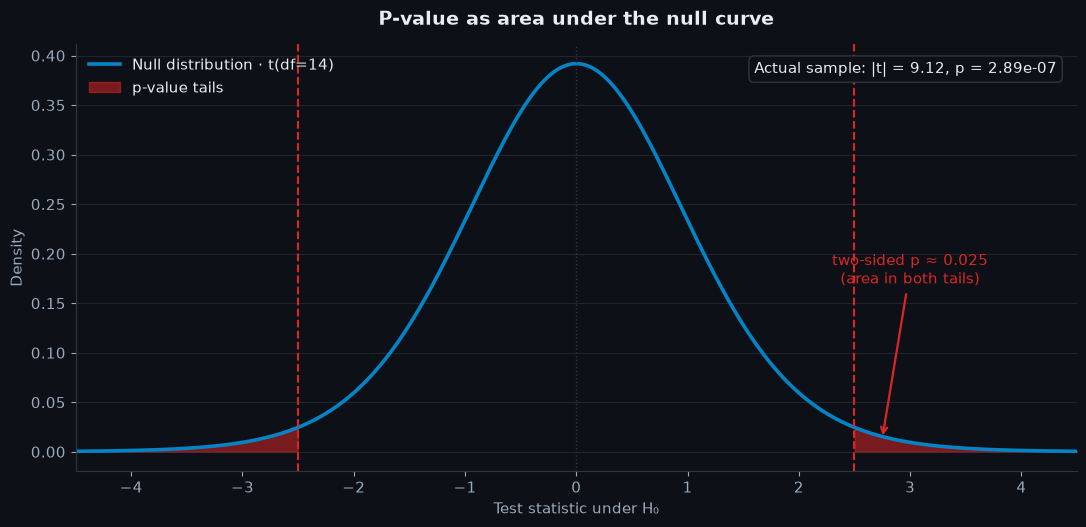

Visualization saved: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l2_type_i_vs_type_ii.png


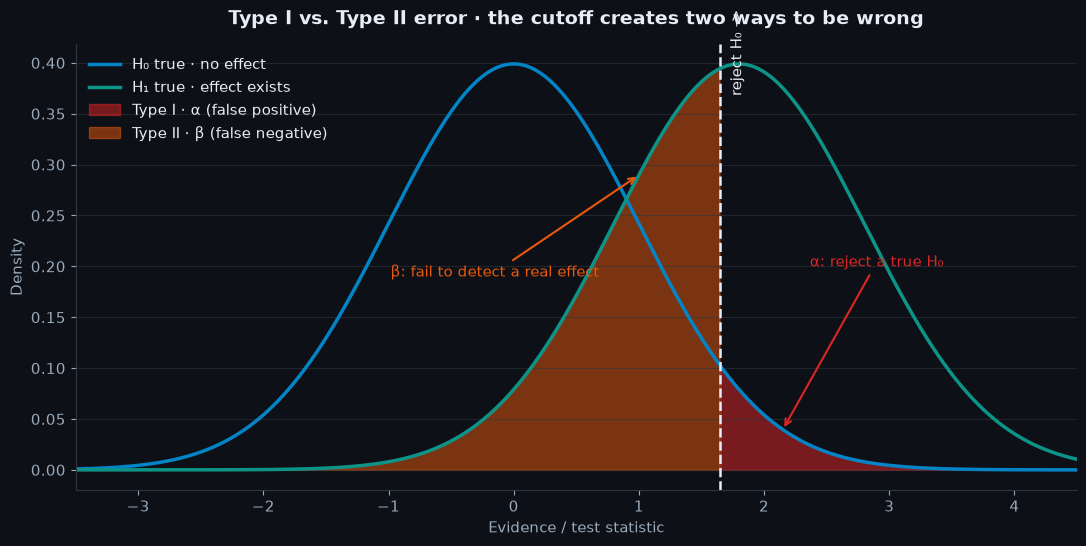

Visualization saved: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\learning\l2_confidence_interval.png


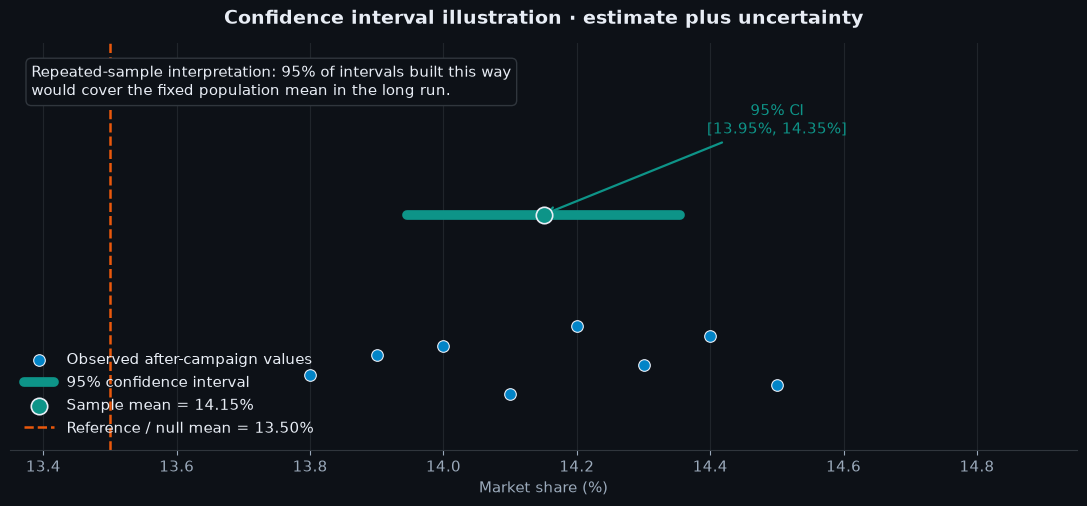

95% CI for the after-campaign mean: [13.945, 14.355]%


In [2]:
# ──────────────────────────────────────────────────────────────
# Three visual explanations — p-value, errors, confidence interval
# ──────────────────────────────────────────────────────────────
from pathlib import Path
import matplotlib.pyplot as plt

# Keep the learning series visual language aligned with L0/L1.
BG, INK, MUTED, GRID = "#0d1117", "#e8edf5", "#9baabb", "#30363d"
AZUL, TIJOLO, TEAL, AMBAR = "#0284c7", "#dc2626", "#0d9488", "#ea580c"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": INK,
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "grid.alpha": 0.55,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
})

NOTEBOOK_ROOT = Path(r"C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva")
OUT_DIR = NOTEBOOK_ROOT / "outputs" / "learning"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def save_learning_figure(fig, filename):
    path = OUT_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor=BG)
    print(f"Visualization saved: {path}")
    return path


# 1) P-value = probability mass in the tails under H₀.
# The observed t in the small teaching sample is very extreme (t≈9.1),
# so a t=2.5 illustration keeps the shaded tails visible at slide scale.
df_test = len(before) + len(after) - 2
t_observed = abs(float(t_stat))
t_illustrative = 2.5
p_illustrative = 2 * stats.t.sf(t_illustrative, df=df_test)
x_curve = np.linspace(-4.5, 4.5, 1200)
y_curve = stats.t.pdf(x_curve, df=df_test)

fig_p, ax = plt.subplots(figsize=(11, 5.4))
ax.plot(x_curve, y_curve, color=AZUL, linewidth=2.6, label=f"Null distribution · t(df={df_test})")
ax.fill_between(x_curve, 0, y_curve, where=x_curve <= -t_illustrative,
                color=TIJOLO, alpha=0.52, label="p-value tails")
ax.fill_between(x_curve, 0, y_curve, where=x_curve >= t_illustrative,
                color=TIJOLO, alpha=0.52)
ax.axvline(-t_illustrative, color=TIJOLO, linestyle="--", linewidth=1.5)
ax.axvline(t_illustrative, color=TIJOLO, linestyle="--", linewidth=1.5)
ax.axvline(0, color=GRID, linestyle=":", linewidth=1)
ax.annotate(
    f"two-sided p ≈ {p_illustrative:.3f}\n(area in both tails)",
    xy=(t_illustrative + 0.25, stats.t.pdf(t_illustrative, df_test) * 0.55),
    xytext=(3.0, 0.17), color=TIJOLO, ha="center",
    arrowprops=dict(arrowstyle="->", color=TIJOLO, lw=1.6),
)
ax.text(
    0.98, 0.96,
    f"Actual sample: |t| = {t_observed:.2f}, p = {p_value:.2e}",
    transform=ax.transAxes, ha="right", va="top", color=INK,
    bbox=dict(boxstyle="round,pad=0.35", facecolor=BG, edgecolor=GRID),
)
ax.set_title("P-value as area under the null curve", pad=14)
ax.set_xlabel("Test statistic under H₀")
ax.set_ylabel("Density")
ax.set_xlim(-4.5, 4.5)
ax.grid(axis="y", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, labelcolor=INK, loc="upper left")
fig_p.tight_layout()
save_learning_figure(fig_p, "l2_p_value_area.png")
plt.show()
plt.close(fig_p)


# 2) One rejection cutoff creates two distinct errors.
x_error = np.linspace(-3.5, 4.5, 1200)
null_density = stats.norm.pdf(x_error, loc=0, scale=1)
alt_density = stats.norm.pdf(x_error, loc=1.8, scale=1)
critical_value = stats.norm.ppf(0.95)  # one-sided alpha = 5%

fig_err, ax = plt.subplots(figsize=(11, 5.6))
ax.plot(x_error, null_density, color=AZUL, linewidth=2.5, label="H₀ true · no effect")
ax.plot(x_error, alt_density, color=TEAL, linewidth=2.5, label="H₁ true · effect exists")
ax.fill_between(x_error, 0, null_density, where=x_error >= critical_value,
                color=TIJOLO, alpha=0.52, label="Type I · α (false positive)")
ax.fill_between(x_error, 0, alt_density, where=x_error < critical_value,
                color=AMBAR, alpha=0.50, label="Type II · β (false negative)")
ax.axvline(critical_value, color=INK, linestyle="--", linewidth=1.8)
ax.text(critical_value + 0.08, 0.41, "reject H₀ ->", color=INK, rotation=90,
        va="center", ha="left")
ax.annotate("α: reject a true H₀", xy=(2.15, stats.norm.pdf(2.15)),
            xytext=(2.9, 0.20), color=TIJOLO, ha="center",
            arrowprops=dict(arrowstyle="->", color=TIJOLO, lw=1.5))
ax.annotate("β: fail to detect a real effect", xy=(1.0, stats.norm.pdf(1.0, 1.8)),
            xytext=(-0.15, 0.19), color=AMBAR, ha="center",
            arrowprops=dict(arrowstyle="->", color=AMBAR, lw=1.5))
ax.set_title("Type I vs. Type II error · the cutoff creates two ways to be wrong", pad=14)
ax.set_xlabel("Evidence / test statistic")
ax.set_ylabel("Density")
ax.set_xlim(-3.5, 4.5)
ax.grid(axis="y", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, labelcolor=INK, loc="upper left")
fig_err.tight_layout()
save_learning_figure(fig_err, "l2_type_i_vs_type_ii.png")
plt.show()
plt.close(fig_err)


# 3) A confidence interval is a range around an estimate, not a guarantee.
sample = np.asarray(after, dtype=float)
mean_after = float(sample.mean())
se_after = float(stats.sem(sample))
df_ci = len(sample) - 1
critical_t = float(stats.t.ppf(0.975, df=df_ci))
ci_low = mean_after - critical_t * se_after
ci_high = mean_after + critical_t * se_after

fig_ci, ax = plt.subplots(figsize=(11, 5.2))
y_points = np.linspace(0.18, 0.34, len(sample))
ax.scatter(sample, y_points, s=70, color=AZUL, edgecolor=INK, linewidth=0.8,
           zorder=3, label="Observed after-campaign values")
ax.plot([ci_low, ci_high], [0.60, 0.60], color=TEAL, linewidth=7,
        solid_capstyle="round", zorder=2, label="95% confidence interval")
ax.scatter([mean_after], [0.60], s=140, color=TEAL, edgecolor=INK,
           linewidth=1.2, zorder=4, label=f"Sample mean = {mean_after:.2f}%")
ax.axvline(13.5, color=AMBAR, linestyle="--", linewidth=1.8,
           label="Reference / null mean = 13.50%")
ax.annotate(
    f"95% CI\n[{ci_low:.2f}%, {ci_high:.2f}%]",
    xy=(mean_after, 0.60), xytext=(mean_after + 0.35, 0.82),
    color=TEAL, ha="center", va="center",
    arrowprops=dict(arrowstyle="->", color=TEAL, lw=1.6),
)
ax.text(
    0.02, 0.95,
    "Repeated-sample interpretation: 95% of intervals built this way\n"
    "would cover the fixed population mean in the long run.",
    transform=ax.transAxes, ha="left", va="top", color=INK,
    bbox=dict(boxstyle="round,pad=0.35", facecolor=BG, edgecolor=GRID),
)
ax.set_title("Confidence interval illustration · estimate plus uncertainty", pad=14)
ax.set_xlabel("Market share (%)")
ax.set_yticks([])
ax.set_ylim(0.05, 1.0)
ax.set_xlim(min(sample.min(), ci_low) - 0.45, max(sample.max(), ci_high) + 0.45)
ax.grid(axis="x", linewidth=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(frameon=False, labelcolor=INK, loc="lower left")
fig_ci.tight_layout()
save_learning_figure(fig_ci, "l2_confidence_interval.png")
plt.show()
plt.close(fig_ci)

print(f"95% CI for the after-campaign mean: [{ci_low:.3f}, {ci_high:.3f}]%")

### Interpreting Results

```
T-statistic: 7.854
P-value: 0.000021
Significant at 5%? YES

→ We can reject the null hypothesis
→ The campaign DID increase market share
→ This result would happen by chance less than 0.002%
```

---

## Executive Takeaway

### 1. One Sentence Summary
Hypothesis testing is how we distinguish real business impacts from random variation — it tells us whether to trust a result or dismiss it as noise.

### 2. One Number to Remember
**0.05 (5%)** — The standard threshold. If p < 0.05, the result is statistically significant. If p ≥ 0.05, we can't rule out chance.

### 3. One Question to Ask Your Analytics Team
"What's is the p-value, and is it below 0.05?" — This shows you understand that statistical significance matters, not just the headline number.

---

## Common Business Applications

| Business Question | Test Type |
|------------------|-----------|
| Did sales increase after campaign? | Two-sample t-test |
| Is supplier A better than B? | Paired t-test |
| Are clicks different across 3 ad designs? | ANOVA |
| Is there a relationship between price and demand? | Correlation test |

---

## Red Flags to Watch

1. **No p-value reported** — Always ask for it
2. **"Significant" without the number** — Demand the actual p-value
3. **Small sample, big claims** — Less data = less reliable
4. **Multiple tests, one success** — If you test 20 things, one will be "significant" by chance

---

## Next Step

→ **L3: Linear Regression** — What if you want to predict outcomes, not just test differences?

---

*Part of the Executive Data Science Learning Progression*
*Links to: NB-02 Supply Chain, NB-08 Backtesting*